In [2]:
!pip install pandas numpy scikit-learn matplotlib


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score



In [10]:
from sklearn.datasets import load_breast_cancer
data = load_breast_cancer()
X=pd.DataFrame(data.data,columns=data.feature_names)
y=pd.Series(data.target)

In [11]:
X_train, X_test, y_train, y_test =train_test_split(X, y, test_size=0.2)
model = LogisticRegression(max_iter=1000)
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
print("Initial accuracy:",accuracy_score(y_test,y_pred))

Initial accuracy: 0.9473684210526315


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [12]:
def evaluate_model(y_true,y_pred):
    return{
        "accuracy":accuracy_score(y_true,y_pred),
        "precision":precision_score(y_true,y_pred),
        "f1":f1_score(y_true,y_pred),
        "recall":recall_score(y_true,y_pred)
    }

In [13]:
resutls=[]
for day in range(10):
  X_sample =X.sample(frac=0.2)
  Y_sample=y[X_sample.index]
  y_pred =model.predict(X_sample)

  metrics=evaluate_model(Y_sample,y_pred)
  metrics["day"]=day
  resutls.append(metrics)

df_results=pd.DataFrame(resutls)
df_results



,accuracy,precision,f1,recall,day
0,0.964912,0.974026,0.974026,0.974026,0
1,0.956140,0.961538,0.967742,0.974026,1
2,0.973684,1.000000,0.979310,0.959459,2
3,0.947368,0.940299,0.954545,0.969231,3
4,0.973684,0.985915,0.979021,0.972222,4
5,0.956140,0.951613,0.959350,0.967213,5
6,0.956140,0.972973,0.966443,0.960000,6
7,0.929825,0.940299,0.940299,0.940299,7
8,0.947368,0.955224,0.955224,0.955224,8
9,0.938596,0.937500,0.944882,0.952381,9


<function matplotlib.pyplot.show(close=None, block=None)>

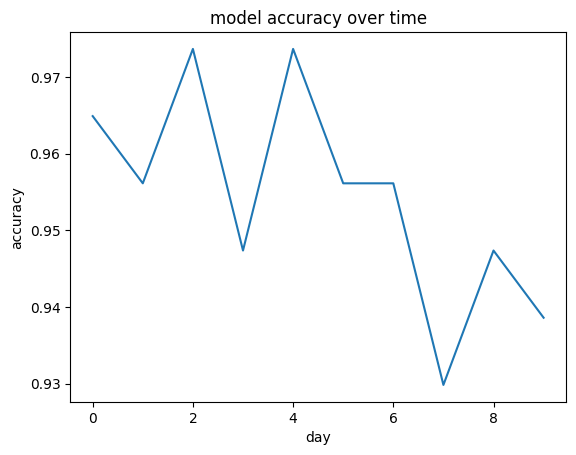

In [14]:
plt.figure()
plt.plot(df_results["day"],df_results["accuracy"],label="accuracy")
plt.xlabel("day")
plt.ylabel("accuracy")
plt.title("model accuracy over time")
plt.show

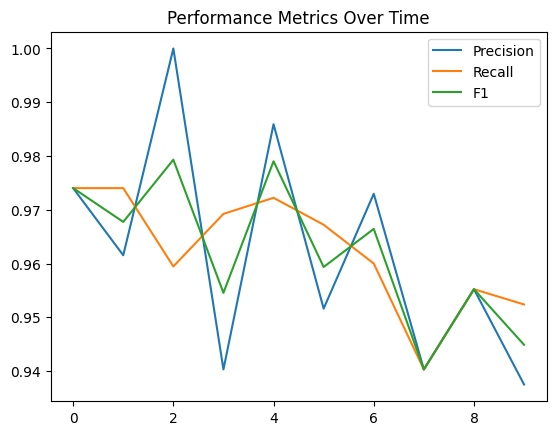

In [17]:
plt.figure()
plt.plot(df_results["day"], df_results["precision"])
plt.plot(df_results["day"], df_results["recall"])
plt.plot(df_results["day"], df_results["f1"])
plt.legend(["Precision", "Recall", "F1"])
plt.title("Performance Metrics Over Time")
plt.show()

In [18]:
df_results.to_csv("model_monitoring_results.csv", index=False)

In [24]:
results = []
for day in range(25):
    X_sample = X.sample(frac=0.2)
    y_sample = y.loc[X_sample.index]
    y_pred = model.predict(X_sample)

    if day > 10:
        noise = np.random.rand(len(y_pred)) < 0.1
        y_pred = np.where(noise, 1 - y_pred, y_pred)

    metrics = evaluate_model(y_sample, y_pred)
    metrics["day"] = day

    results.append(metrics)

df_results = pd.DataFrame(results)
df_results

,accuracy,precision,f1,recall,day
0,0.956140,0.983607,0.960000,0.937500,0
1,0.956140,0.945205,0.965035,0.985714,1
2,0.947368,0.944444,0.957746,0.971429,2
3,0.964912,0.970588,0.970588,0.970588,3
4,0.982456,0.986301,0.986301,0.986301,4
5,0.964912,0.985714,0.971831,0.958333,5
6,0.956140,0.960000,0.966443,0.972973,6
7,0.921053,0.941176,0.934307,0.927536,7
8,0.973684,0.970149,0.977444,0.984848,8
9,0.947368,0.969231,0.954545,0.940299,9


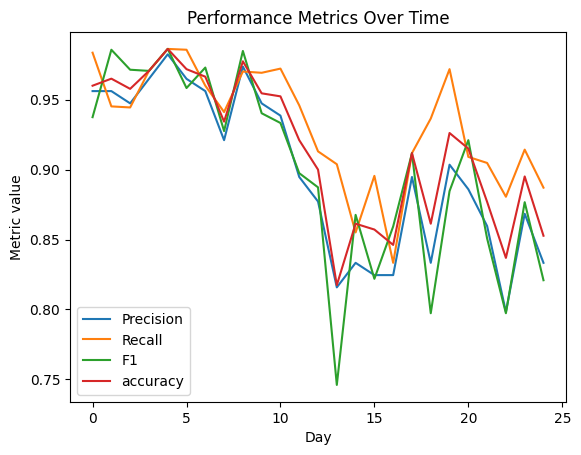

In [30]:
plt.figure()
plt.plot(df_results["day"], df_results["accuracy"])
plt.plot(df_results["day"], df_results["precision"])
plt.plot(df_results["day"], df_results["recall"])
plt.plot(df_results["day"], df_results["f1"])
plt.xlabel("Day")
plt.ylabel("Metric value")
plt.title("Model monitoring dashboard")
plt.legend(["Precision", "Recall", "F1","accuracy"])
plt.title("Performance Metrics Over Time")
plt.savefig("dashboard.png")
plt.show()
